<a href="https://colab.research.google.com/github/Asmitx026/AI-Lab/blob/main/assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q1. Perform A* search algorithm on a directed weighted graph.

In [16]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('G',2)],
    'F': [('G', 3)],
    'G': []
}

heuristic = {'A': 7, 'B': 6, 'C': 2, 'D': 5, 'E': 2, 'F': 1, 'G': 0}

In [17]:
def astar(graph: dict, heuristic: dict[str,int], start: str, goal: str):
    pq = [(heuristic[start], 0, start, [start])]
    visited = set()

    while pq:
      f,g, node, path = heapq.heappop(pq)
      if node ==  goal:
        return path, g

      if node in visited:
        continue

      visited.add(node)
      for neighbor, cost in graph[node]:
          new_g = g + cost
          new_f = new_g + heuristic[neighbor]
          heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return None, float('inf')

In [18]:
path, cost = astar(graph, heuristic, 'A', 'G')
print("Shortest path:", path)
print(' -> '.join(path))
print("Total Cost:", cost)

Shortest path: ['A', 'B', 'E', 'G']
A -> B -> E -> G
Total Cost: 8


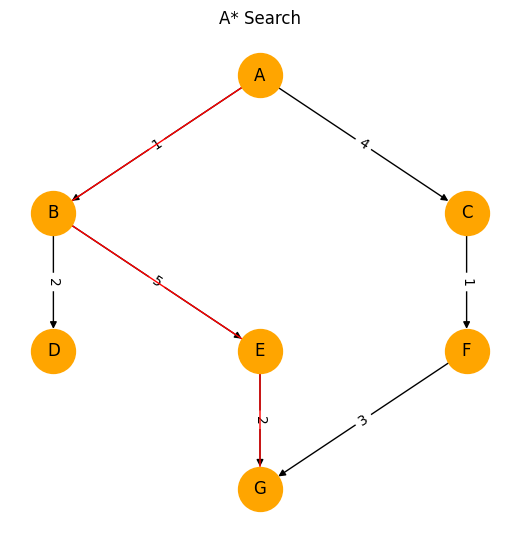

In [19]:
G = nx.DiGraph()

plt.figure(figsize=(5,5))
pos = {
    'A': (0, 3),
    'B': (-1, 2),
    'C': (1, 2),
    'D': (-1, 1),
    'E': (0, 1),
    'F': (1, 1),
    'G': (0, 0)
}

for node, neighbors in graph.items():
    for (neighbor, weight) in neighbors:
        G.add_edge(node, neighbor, weight=weight)
nx.draw(G, pos, with_labels=True, node_color='orange', node_size=1000)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', arrows=True)

plt.title("A* Search")
plt.axis('off')
plt.show()

### Q1. Perform AO* search algorithm on a directed weighted graph.

In [33]:
graph = {
    'A': {'type': 'OR', 'children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND', 'children': [('D', 1), ('E', 1)]},
    'C': {'type': 'OR', 'children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 6}
}

In [36]:
def ao_star(node):
    info=graph[node]

    if info['type']=='LEAF':
        return info['cost'],[node]

    if info['type']=='OR':
        best_cost=float('inf')
        best_path=[]

        for child,edge_cost in info['children']:
            child_cost,child_path = ao_star(child)
            total =edge_cost+child_cost

            if total < best_cost:
                best_cost=total
                best_path=[node] + child_path
        return best_cost,best_path

    if info['type']=='AND':
        total_cost=0
        full_path=[node]

        for child,edge_cost in info['children']:
            child_cost,child_path=ao_star(child)
            total_cost+=edge_cost+child_cost
            full_path+=child_path
        return total_cost, full_path

In [37]:
cost, path = aostar('A')
print("Cost:", cost)
print("Path:", path)
print(' -> '.join(path))

Cost: 6
Path: ['A', 'B', 'D', 'E']
A -> B -> D -> E


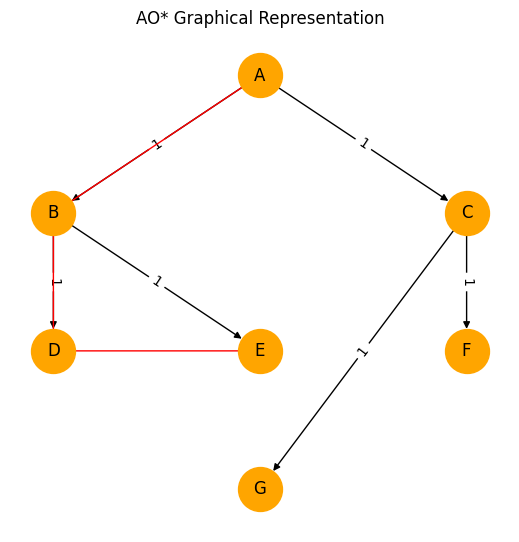

In [27]:
G = nx.DiGraph()
pos = {
    'A':(0,3),
    'B':(-1,2),
    'C':(1,2),
    'D':(-1,1),
    'E':(0,1),
    'F':(1,1),
    'G':(0,0)
}

for node,info in graph.items():
    if 'children' in info:
        for child,weight in info['children']:
            G.add_edge(node,child,weight=weight)

plt.figure(figsize=(5,5))
nx.draw(G, pos, with_labels=True, node_color='orange', node_size=1000, arrows=True)

edge_labels=nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)

path_edges=list(zip(path[:-1],path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', arrows=True)

plt.title("AO* Graphical Representation")
plt.axis('off')
plt.show()